In [1]:
from torchvision.datasets import Food101
from torchvision import transforms
train_transforms = transforms.Compose([transforms.Resize([224, 224]),
                                       transforms.RandomResizedCrop(224),
                                        transforms.RandomHorizontalFlip(),
                                        transforms.ColorJitter(0.2,0.2,0.2),

                                    transforms.ToTensor(),
                                     transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
test_transforms = transforms.Compose([transforms.Resize([128, 128]),
                                      transforms.ToTensor()])

In [2]:
train_data = Food101(download=True,
                     root="data",
                     split="train",
                     transform=train_transforms)
test_data = Food101(download=True,
                    root='data',
                    split="test",
                    transform=test_transforms)

In [3]:
classes = test_data.classes

In [4]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(train_data,
                              128,
                              True,
                              num_workers=10)
test_dataloader = DataLoader(test_data,
                             64,
                             False,
                             num_workers=6)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.465708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.465708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6330532..2.169412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4229691..1.9254032].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..2.5702832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.465708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9831933..2

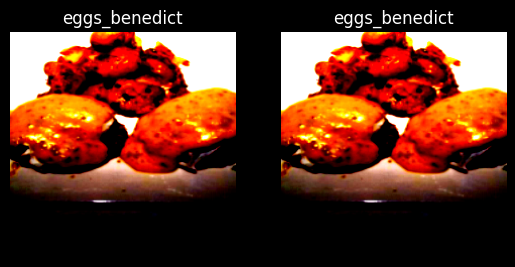

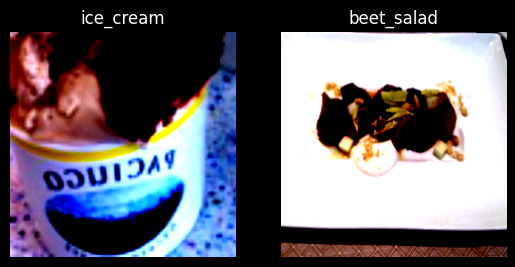

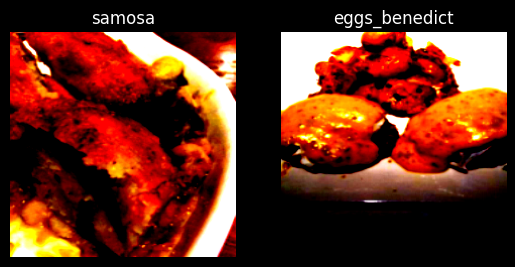

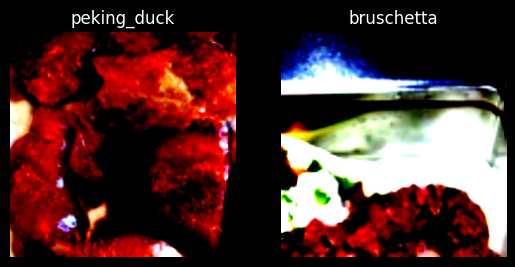

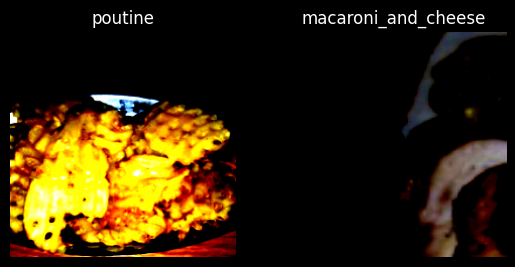

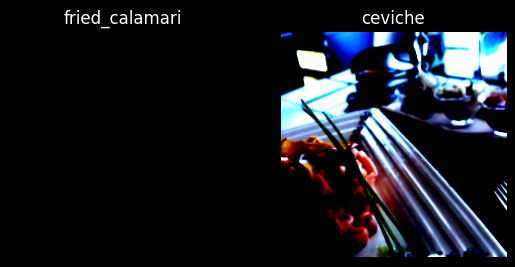

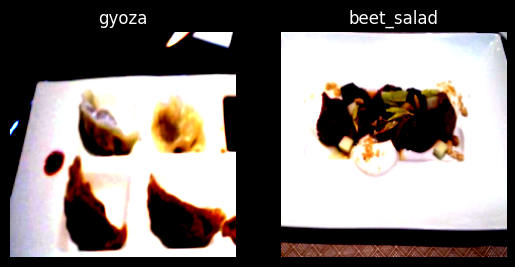

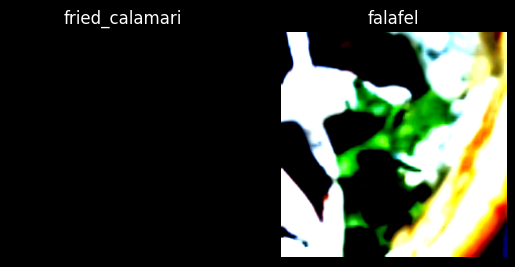

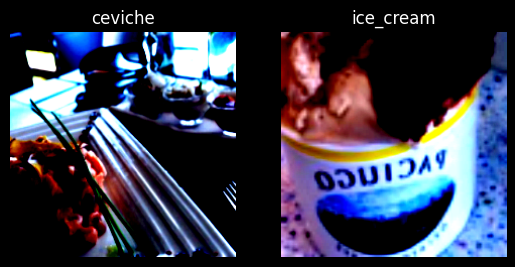

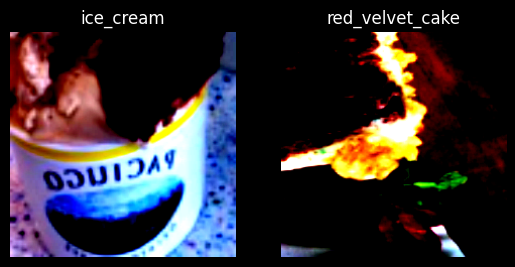

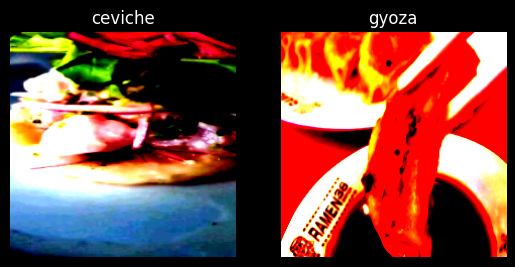

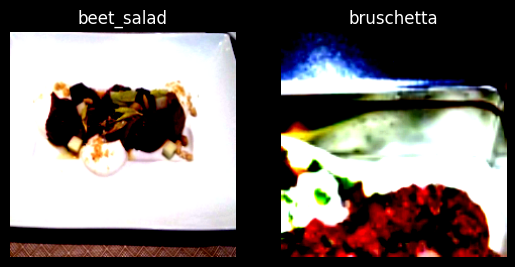

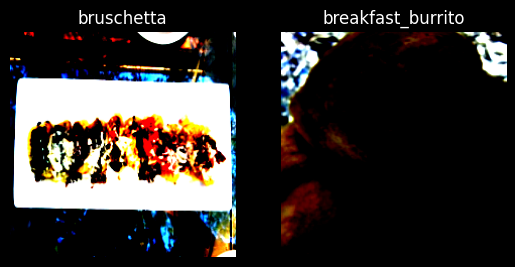

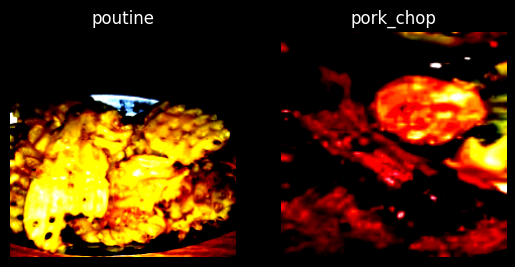

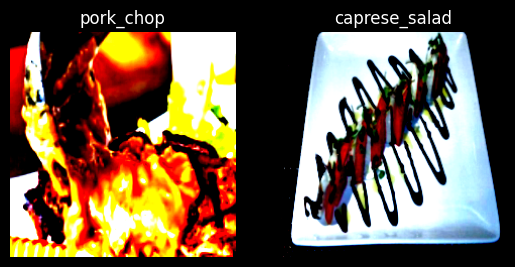

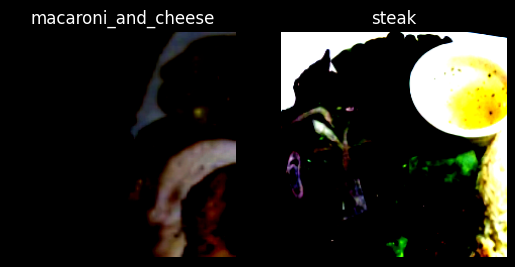

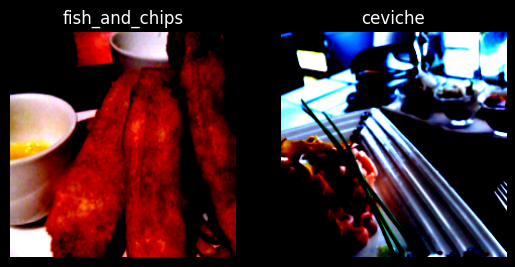

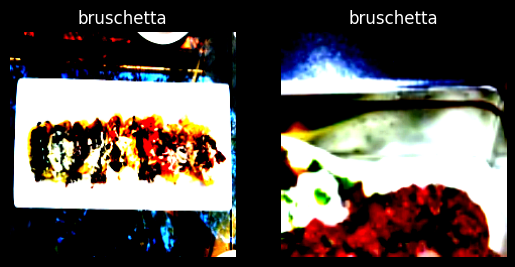

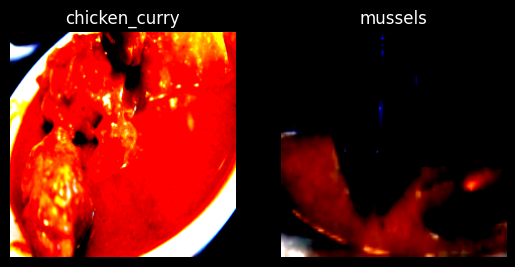

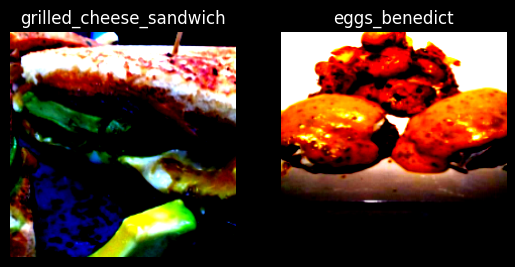

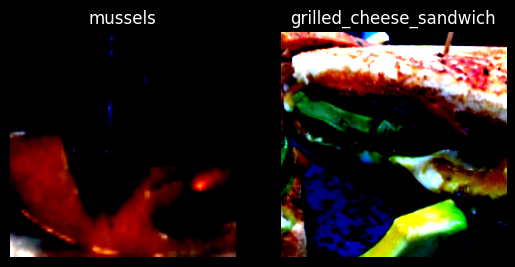

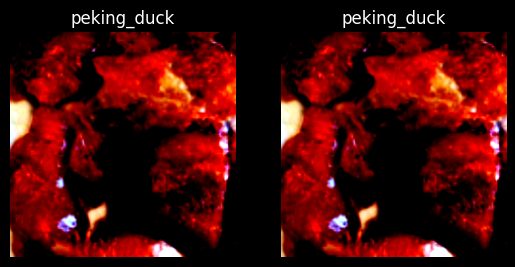

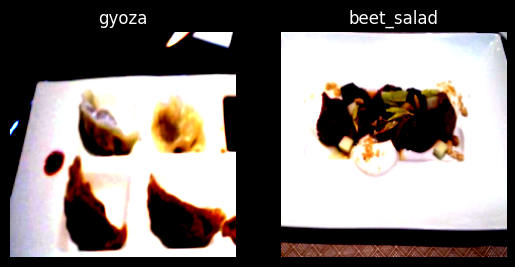

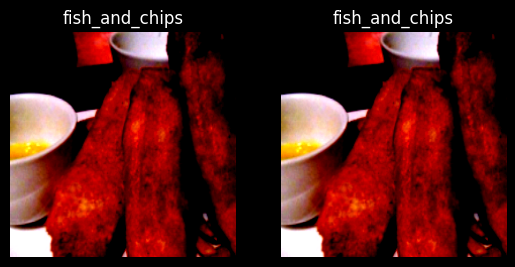

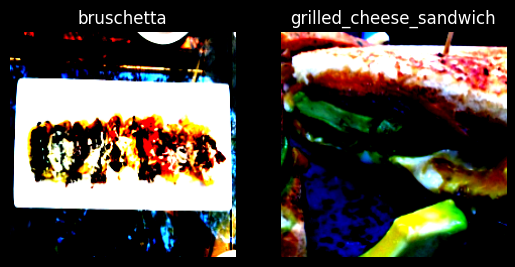

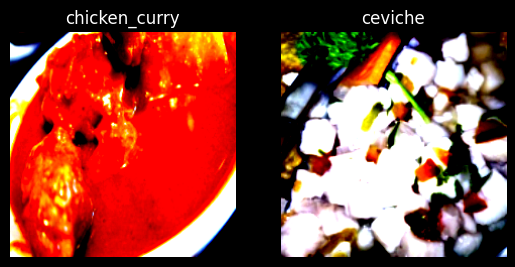

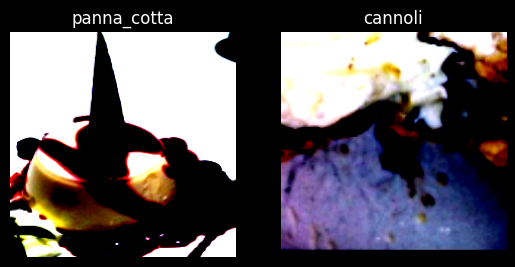

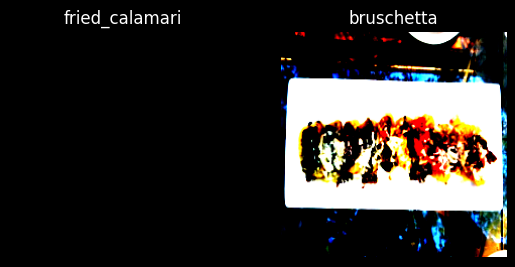

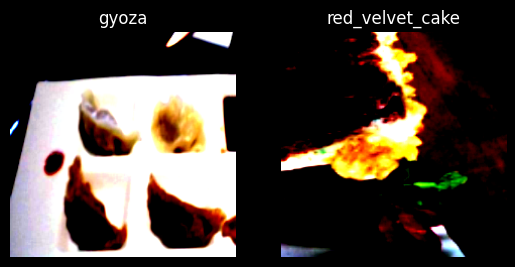

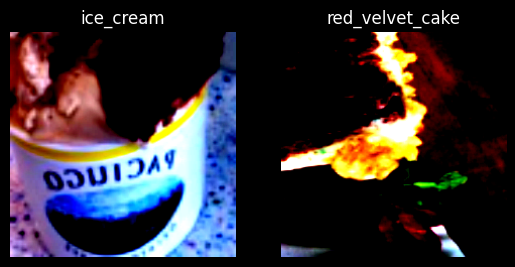

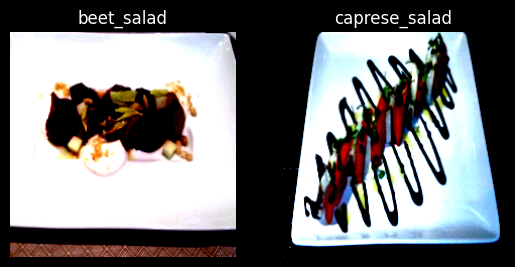

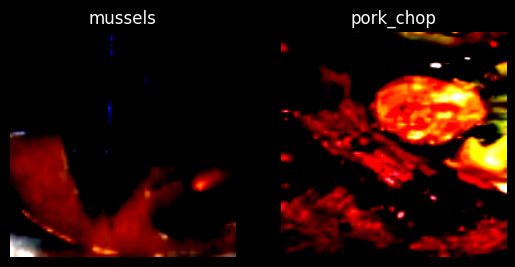

In [5]:
from matplotlib import pyplot as plt
import numpy as np
x_btch, y_btch = next(iter(train_dataloader))
for i in range(32):
    ridx = np.random.randint(0, 32)
    img = x_btch[ridx].squeeze().permute(1, 2, 0).numpy()
    lbl = classes[y_btch[ridx].item()]
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(img)
    ax[0].set_title(lbl)
    ax[0].axis(False)
    ridx = np.random.randint(0, 32)
    img = x_btch[ridx].squeeze().permute(1, 2, 0).numpy()
    lbl = classes[y_btch[ridx].item()]
    ax[1].imshow(img)
    ax[1].set_title(lbl)
    ax[1].axis(False)

In [6]:
import torch
from torch import nn


# -----------------------------
# basic block (resnet18/34)
# -----------------------------
class BasicBlock(nn.Module):
    expansion = 1  # dont worry abt this rn

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # main path (the "real" conv stuff)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # shortcut path (skip connection)
        # if shape changed → we fix it with a 1x1 conv
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x  # lil homie that skips

        out = self.conv1(x)
        out = self.bn1(out)
        out = nn.functional.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # add skip connection (identity) to the processed tensor
        out += self.shortcut(identity)
        out = nn.functional.relu(out)

        return out


# -----------------------------
# resnet main model
# -----------------------------
class ResNet18(nn.Module):
    def __init__(self, num_classes=1000):
        super().__init__()

        # first layer (big boi conv)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2,
                               padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # the 4 resnet stages (each is 2 blocks for resnet18)
        self.layer1 = self.make_layer(64, 64, blocks=2, stride=1)
        self.layer2 = self.make_layer(64, 128, blocks=2, stride=2)
        self.layer3 = self.make_layer(128, 256, blocks=2, stride=2)
        self.layer4 = self.make_layer(256, 512, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(512, num_classes))

    def make_layer(self, in_channels, out_channels, blocks, stride):
        layers = []
        layers.append(BasicBlock(in_channels, out_channels, stride))

        # after first block the channels stay same
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


# -----------------------------
# create the model
# -----------------------------
model = ResNet18(num_classes=101).cuda()  # food101 ready


In [7]:
from torch import optim
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = optim.Adam(model.parameters(), 3e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
sheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, 200)

In [8]:
# ...existing code...
from torch import optim
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter

# create writer once and close after training (not every epoch)
writer = SummaryWriter(log_dir='runs')

epochbatch = len(train_dataloader)


# ...existing code...
def evaluate_model(model, loader, device):
    """Calculates the accuracy of the model on the test/validation set."""
    model.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    accuracy = 100. * correct / total
    return accuracy

def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs, device):
    best_acc = 0.0
    print(f"Starting training on {device}...")

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch_idx, (inputs, targets) in enumerate(train_bar):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            # step scheduler per batch if appropriate
            scheduler.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            train_bar.set_postfix({
                'Loss': f'{train_loss/(batch_idx+1):.4f}',
                'Acc': f'{100.*correct/total:.2f}%',
                'LR': f'{optimizer.param_groups[0]["lr"]:.6f}'
            })

        # Evaluate on the test set after each epoch
        test_acc = evaluate_model(model, test_loader, device)
        print(f"Test Accuracy after Epoch {epoch+1}: {test_acc:.2f}%")
        writer.add_scalar('Epoch/acc', test_acc, epoch)
        # DO NOT close writer here

        if test_acc > best_acc:
            best_acc = test_acc
            print(f"** New best model saved with accuracy: {best_acc:.2f}% **")
            # save checkpoint if desired

    # close writer after training completes
    writer.close()
    torch.cuda.empty_cache()
    print(f"\nTraining complete. Best Test Accuracy: {best_acc:.2f}%")
# ...existing code...

In [ ]:
train_model(model, train_dataloader, test_dataloader, criterion, optimizer, sheduler, 200, device)